In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

#Data Loading and initial exploration
df = pd.read_csv('laptop_prices.csv', encoding='ISO-8859-1')
print("DATOS CARGDOS, total de registros: ", len(df))
df.info()

DATOS CARGDOS, total de registros:  1275
<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   str    
 1   Product               1275 non-null   str    
 2   TypeName              1275 non-null   str    
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   str    
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   str    
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   str    
 12  IPSpanel              1275 non-null   str    
 13  RetinaDisplay         1275 non-null   str    
 14  CPU_company           1275 non-null   str 

In [ ]:
#Data Cleaning
datos_sin_na=df.dropna()
datos_sin_na.info()

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   str    
 1   Product               1275 non-null   str    
 2   TypeName              1275 non-null   str    
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   str    
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   str    
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   str    
 12  IPSpanel              1275 non-null   str    
 13  RetinaDisplay         1275 non-null   str    
 14  CPU_company           1275 non-null   str    
 15  CPU_freq              1275 non-n

In [ ]:
datos_sin_na["Ram"].value_counts()

Ram
8     613
4     367
16    198
6      35
12     25
32     17
2      16
24      3
64      1
Name: count, dtype: int64

In [ ]:
dummies = pd.get_dummies(datos_sin_na["Ram"],dtype=int)
dummies.info()

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   2       1275 non-null   int64
 1   4       1275 non-null   int64
 2   6       1275 non-null   int64
 3   8       1275 non-null   int64
 4   12      1275 non-null   int64
 5   16      1275 non-null   int64
 6   24      1275 non-null   int64
 7   32      1275 non-null   int64
 8   64      1275 non-null   int64
dtypes: int64(9)
memory usage: 89.8 KB


In [ ]:
datos_sin_na = datos_sin_na.drop(["SecondaryStorage"], axis=1)
datos_sin_na = datos_sin_na.join(dummies)
df.head(5)
df.tail(5)

In [ ]:
df['Company']

0        Apple
1        Apple
2           HP
3        Apple
4        Apple
         ...  
1270    Lenovo
1271    Lenovo
1272    Lenovo
1273        HP
1274      Asus
Name: Company, Length: 1275, dtype: str

In [ ]:
df['Company'].value_counts()

Company
Dell         291
Lenovo       289
HP           268
Asus         152
Acer         101
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64

array([[<Axes: title={'center': 'Inches'}>,
        <Axes: title={'center': 'Ram'}>,
        <Axes: title={'center': 'Weight'}>],
       [<Axes: title={'center': 'Price_euros'}>,
        <Axes: title={'center': 'ScreenW'}>,
        <Axes: title={'center': 'ScreenH'}>],
       [<Axes: title={'center': 'CPU_freq'}>,
        <Axes: title={'center': 'PrimaryStorage'}>,
        <Axes: title={'center': 'SecondaryStorage'}>]], dtype=object)

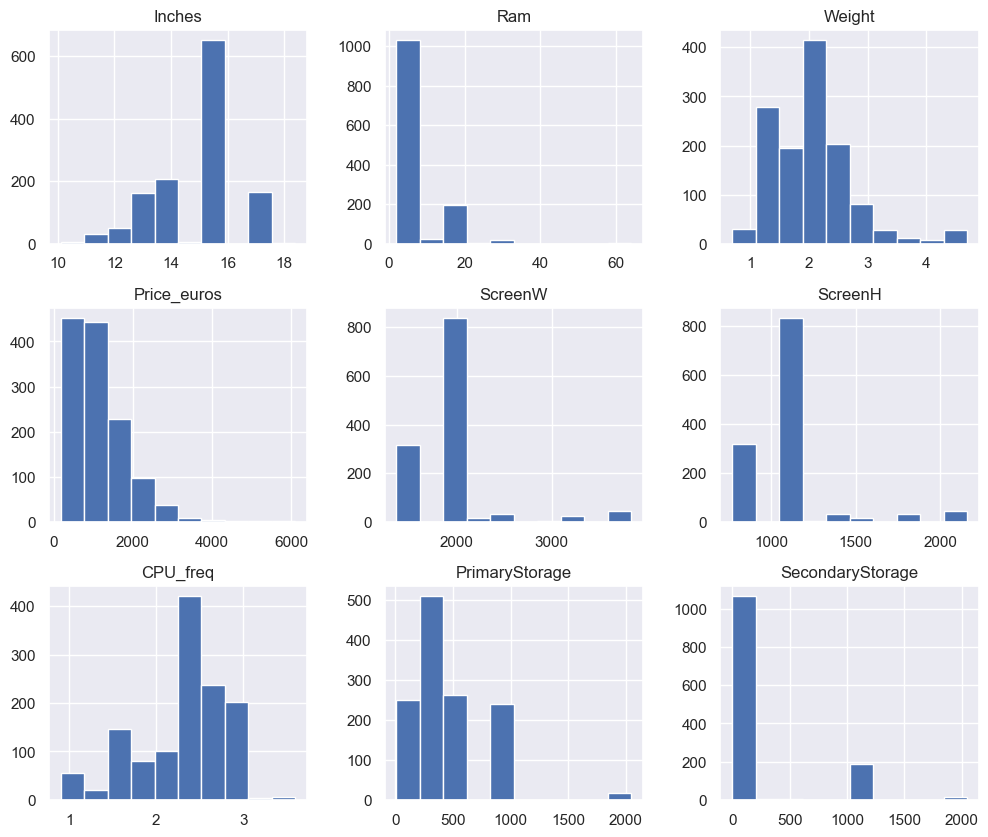

In [ ]:
df.describe()
df.hist()

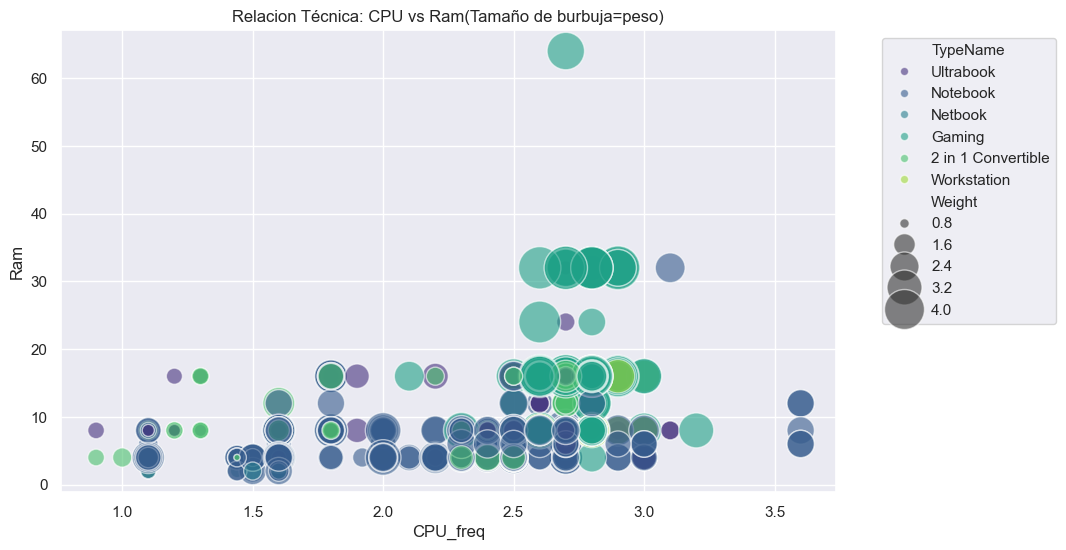

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="CPU_freq",
    y="Ram", 
    size="Weight",
    hue="TypeName", 
    sizes=(20,1000),
    alpha=0.6,
    palette="viridis")

plt.title("Relacion Técnica: CPU vs Ram(Tamaño de burbuja=peso)")
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left')
plt.show()

<Axes: xlabel='OS', ylabel='Price_euros'>

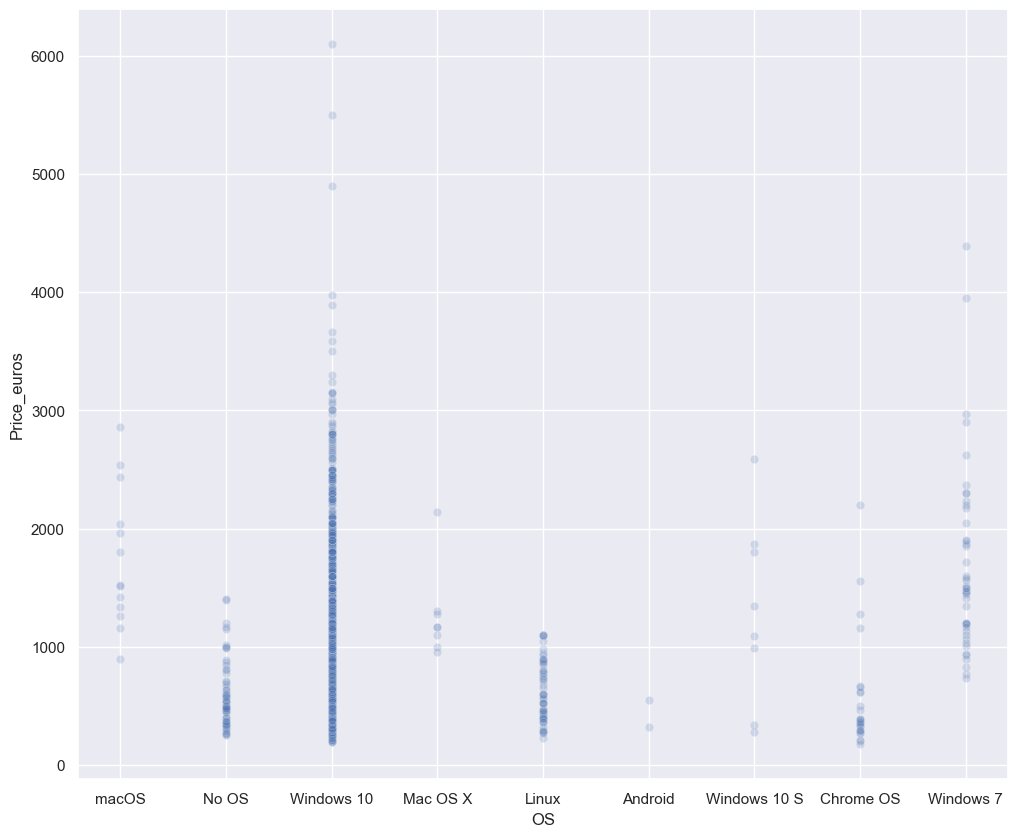

In [ ]:
sns.scatterplot(x='OS', y='Price_euros', data=df, alpha=0.2)

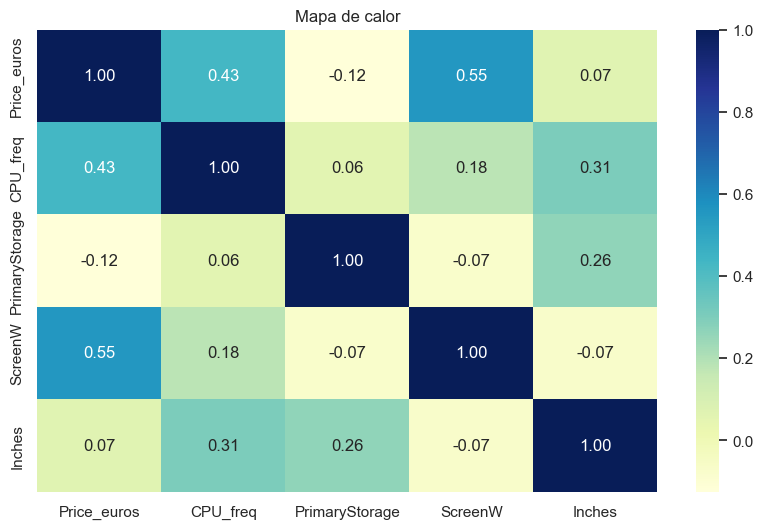

In [ ]:
plt.figure(figsize=(10,6))
columnas_intereses=['Price_euros','CPU_freq','PrimaryStorage', 'ScreenW', 'Inches']
sns.heatmap(df[columnas_intereses].corr(), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Mapa de calor')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

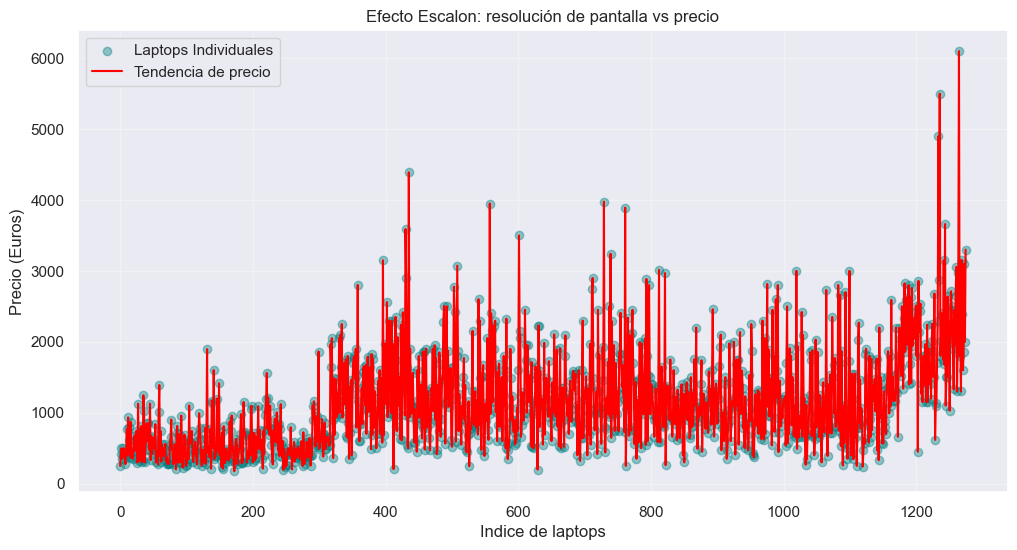

In [ ]:
df_escalon= df.sort_values(by='ScreenW').reset_index()

plt.figure(figsize=(12,6))

plt.scatter(df_escalon.index,df_escalon['Price_euros'],alpha=0.4,color='teal',label='Laptops Individuales')

sns.lineplot(x=df_escalon.index, y=df_escalon['Price_euros'],color='red', label='Tendencia de precio')

plt.title('Efecto Escalon: resolución de pantalla vs precio')
plt.xlabel('Indice de laptops')
plt.ylabel('Precio (Euros)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show

In [ ]:
#Model Training and Evaluation
equis =df[['CPU_freq']]
y =df[['Price_euros']]

X_train, X_test, y_train, y_test = train_test_split (equis, y, test_size=0.2, random_state=42)
modelo_cpu= LinearRegression()
modelo_cpu.fit(X_train, y_train)

print(f"Modelo entrenado. Presicion R2: {modelo_cpu.score(X_test, y_test):.2f}")

Modelo entrenado. Presicion R2: 0.20


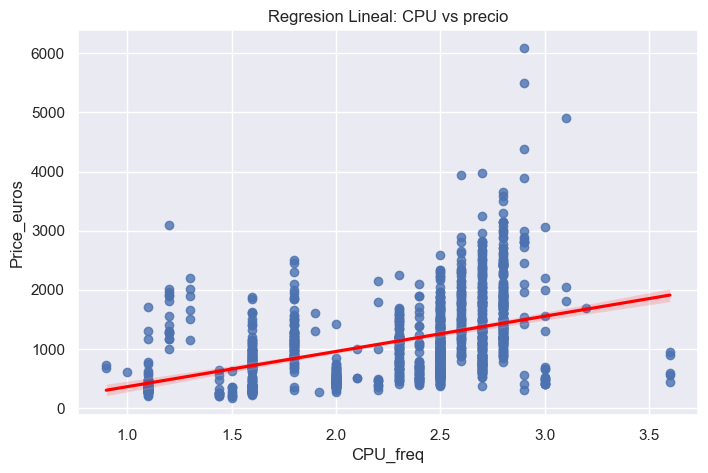

In [ ]:
plt.figure(figsize=(8,5))
sns.regplot(x='CPU_freq', y='Price_euros', data=df, line_kws={"color":"red"} )
plt.title('Regresion Lineal: CPU vs precio')
plt.show()

In [ ]:
X_ent, X_pru, y_ent, y_pru = train_test_split(equis,y)
print (y)

      Price_euros
0         1339.69
1          898.94
2          575.00
3         2537.45
4         1803.60
...           ...
1270       638.00
1271      1499.00
1272       229.00
1273       764.00
1274       369.00

[1275 rows x 1 columns]


In [ ]:
modelo = LinearRegression()
modelo.fit(X_ent, y_ent)
predicciones = modelo.predict(X_pru)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
predicciones

array([[1245.30217535],
       [1848.72189732],
       [ 751.59513009],
       [ 532.16977665],
       [1409.87119043],
       [1245.30217535],
       [ 751.59513009],
       [ 971.02048354],
       [1245.30217535],
       [ 477.31343829],
       [1190.44583698],
       [1190.44583698],
       [ 751.59513009],
       [1409.87119043],
       [1245.30217535],
       [ 751.59513009],
       [1245.30217535],
       [1245.30217535],
       [1464.72752879],
       [ 751.59513009],
       [ 477.31343829],
       [ 751.59513009],
       [1245.30217535],
       [ 971.02048354],
       [1135.58949862],
       [1355.01485207],
       [ 751.59513009],
       [1355.01485207],
       [1245.30217535],
       [1245.30217535],
       [ 861.30780682],
       [ 861.30780682],
       [1519.58386715],
       [1135.58949862],
       [1409.87119043],
       [1245.30217535],
       [ 477.31343829],
       [1190.44583698],
       [1245.30217535],
       [1135.58949862],
       [1245.30217535],
       [ 751.595

In [ ]:
#Model Prediction vs actual values
pd.DataFrame(predicciones)
comparacion = pd.DataFrame({'Predicción': predicciones.flatten(), 'Valor real': y_pru.values.flatten()})
print(comparacion)

      Predicción  Valor real
0    1245.302175       899.0
1    1848.721897       949.0
2     751.595130       349.0
3     532.169777      1262.4
4    1409.871190      1089.0
..           ...         ...
314  1190.445837       769.0
315  1245.302175      2339.0
316   663.824989       549.0
317  1355.014852      1334.0
318   663.824989       210.8

[319 rows x 2 columns]
